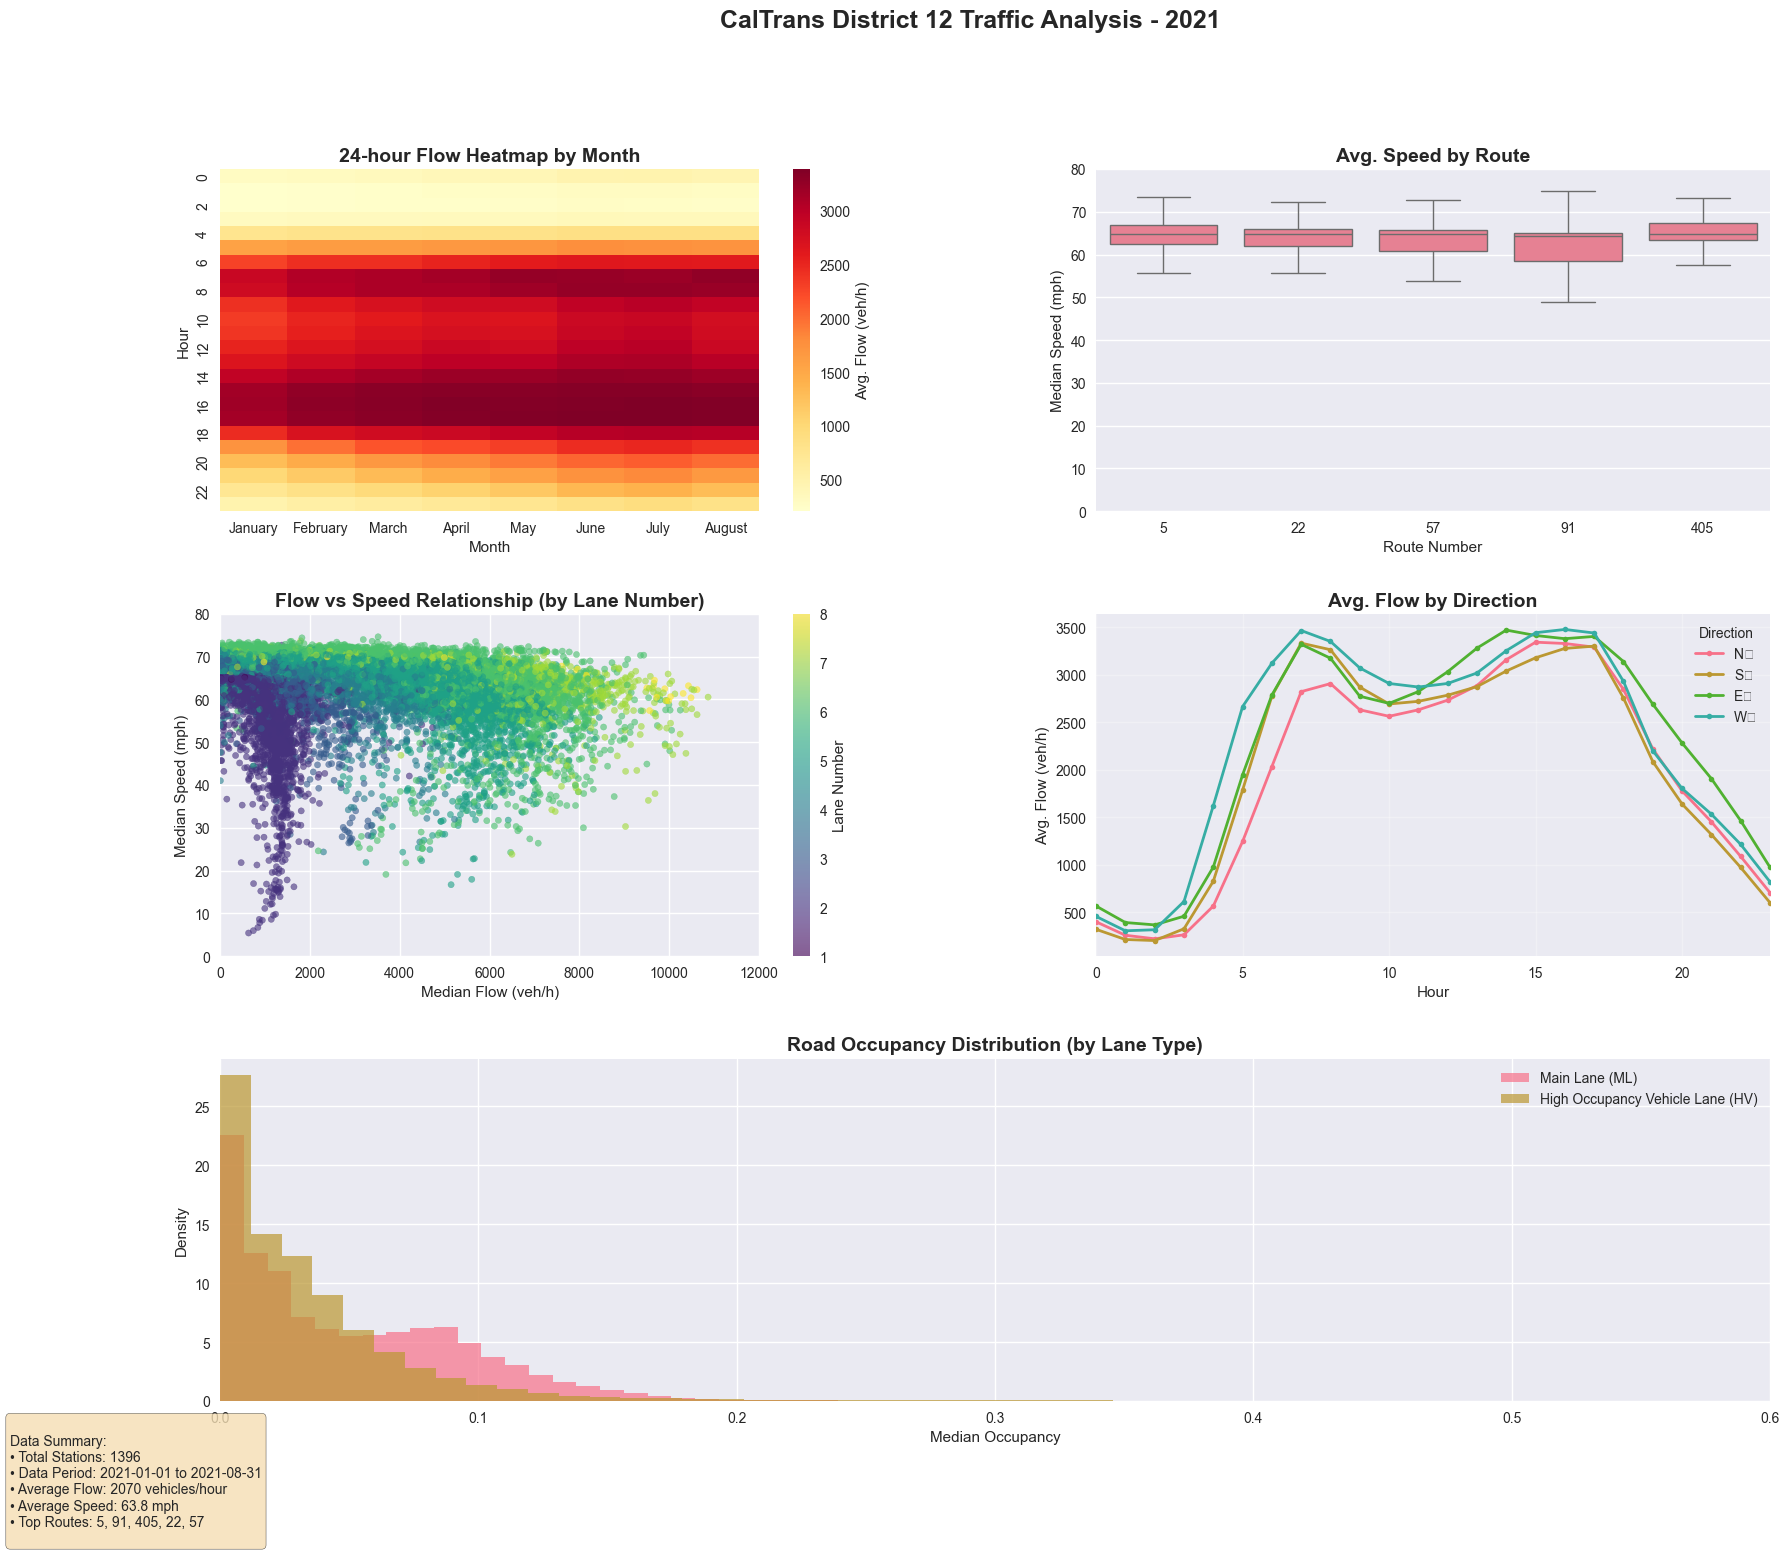

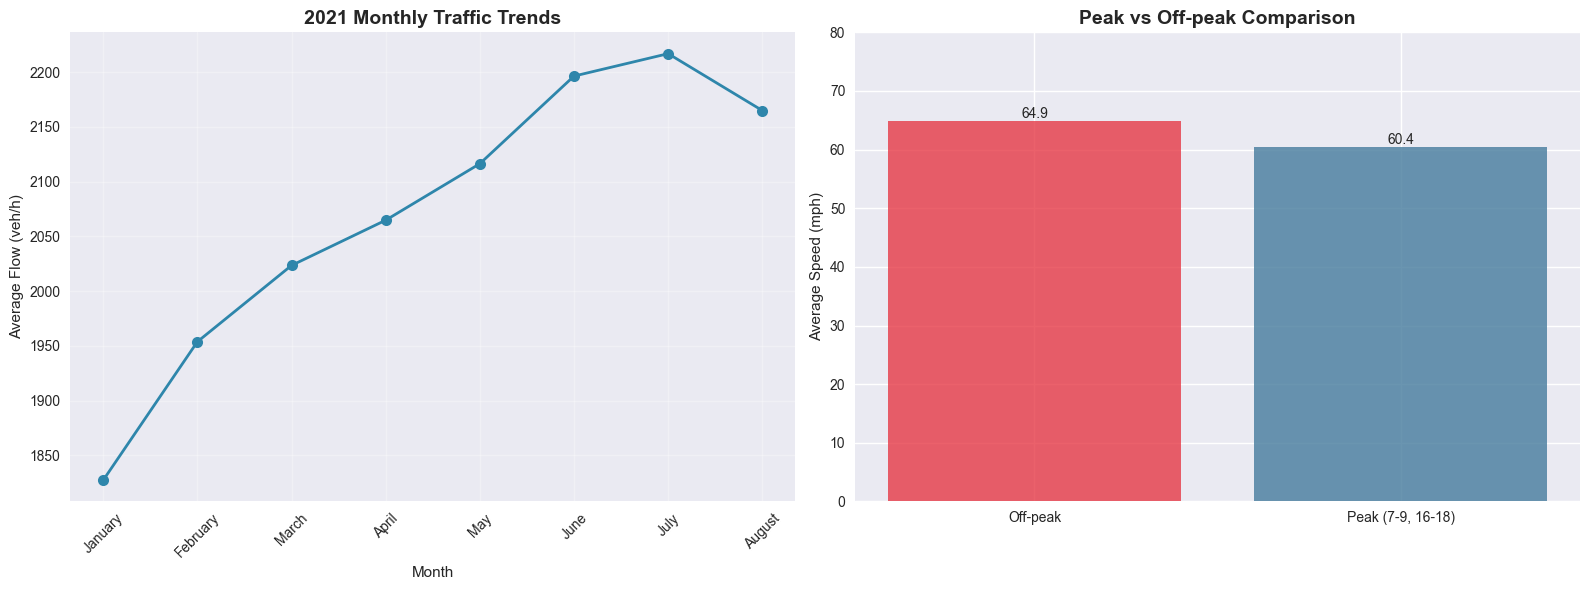

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings("ignore")  # ignore all warnings


# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Read the parquet file
df = pd.read_parquet('../data/processed/2021_station_hour_processed.parquet')

# Create figure with subplots
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# 1.24 hour flow heatmap by month
ax1 = fig.add_subplot(gs[0, 0])
# Create pivot table for heatmap
hourly_monthly_flow = df.pivot_table(
    values='median_flow', 
    index='hour', 
    columns='month', 
    aggfunc='mean'
)
# Reorder months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']
hourly_monthly_flow = hourly_monthly_flow[month_order]

sns.heatmap(
    hourly_monthly_flow, 
    cmap='YlOrRd', 
    ax=ax1,
    cbar_kws={'label': 'Avg. Flow (veh/h)'}
)
ax1.set_title('24-hour Flow Heatmap by Month', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Hour')

# 2. 主要路線平均車速比較 (箱形圖)

ax2 = fig.add_subplot(gs[0, 1])
# Get top 5 routes by data count
top_routes = df['route'].value_counts().head(5).index
route_data = df[df['route'].isin(top_routes)]

sns.boxplot(
    data=route_data, 
    x='route', 
    y='median_speed', 
    ax=ax2,
    showfliers=False
)
ax2.set_title('Avg. Speed by Route', fontsize=14, fontweight='bold')
ax2.set_xlabel('Route Number')
ax2.set_ylabel('Median Speed (mph)')
ax2.set_ylim(0, 80)

# 3. 流量 vs 車速散點圖 (按車道數)
ax3 = fig.add_subplot(gs[1, 0])
# Sample data for better visualization (every 10th point)
sample_df = df.iloc[::10, :]

scatter = ax3.scatter(
    sample_df['median_flow'], 
    sample_df['median_speed'],
    c=sample_df['lanes'],
    cmap='viridis',
    alpha=0.6,
    s=20
)
ax3.set_title('Flow vs Speed Relationship (by Lane Number)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Median Flow (veh/h)')
ax3.set_ylabel('Median Speed (mph)')
ax3.set_xlim(0, 12000)
ax3.set_ylim(0, 80)
plt.colorbar(scatter, ax=ax3, label='Lane Number')

# 4. 各方向高峰時段流量變化 (折線圖)
ax4 = fig.add_subplot(gs[1, 1])
# Calculate average flow by hour and direction
hourly_dir_flow = df.groupby(['hour', 'direction'])['median_flow'].mean().reset_index()

for direction in ['N', 'S', 'E', 'W']:
    dir_data = hourly_dir_flow[hourly_dir_flow['direction'] == direction]
    if not dir_data.empty:
        ax4.plot(dir_data['hour'], dir_data['median_flow'], 
                label=f'{direction}向', linewidth=2, marker='o', markersize=4)

ax4.set_title('Avg. Flow by Direction', fontsize=14, fontweight='bold')
ax4.set_xlabel('Hour')
ax4.set_ylabel('Avg. Flow (veh/h)')
ax4.legend(title='Direction')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 23)

# 5. 佔有率分布直方圖 (按車道類型)
ax5 = fig.add_subplot(gs[2, :])
# Create separate histograms for ML and HV
ml_data = df[df['type'] == 'ML']['median_occup']
hv_data = df[df['type'] == 'HV']['median_occup']

ax5.hist(ml_data, bins=50, alpha=0.7, label='Main Lane (ML)', density=True)
ax5.hist(hv_data, bins=50, alpha=0.7, label='High Occupancy Vehicle Lane (HV)', density=True)

ax5.set_title('Road Occupancy Distribution (by Lane Type)', fontsize=14, fontweight='bold')
ax5.set_xlabel('Median Occupancy')
ax5.set_ylabel('Density')
ax5.legend()
ax5.set_xlim(0, 0.6)

# Add main title
fig.suptitle('CalTrans District 12 Traffic Analysis - 2021', fontsize=18, fontweight='bold', y=0.98)

# Add summary statistics as text
stats_text = f"""
Data Summary:
• Total Stations: {df['station'].nunique()}
• Data Period: 2021-01-01 to 2021-08-31
• Average Flow: {df['median_flow'].mean():.0f} vehicles/hour
• Average Speed: {df['median_speed'].mean():.1f} mph
• Top Routes: {', '.join(map(str, top_routes.tolist()))}
"""
fig.text(0.02, 0.02, stats_text, fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
# plt.savefig('traffic_analysis_dashboard.png', dpi=300, bbox_inches='pad_inches=0.5')
plt.show()

# Additional detailed analysis plots

# Plot 6: Monthly Traffic Trends by Route Type
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Monthly flow trends
monthly_flow = df.groupby('month')['median_flow'].mean().reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']
monthly_flow['month'] = pd.Categorical(monthly_flow['month'], categories=month_order, ordered=True)
monthly_flow = monthly_flow.sort_values('month')

ax1.plot(monthly_flow['month'], monthly_flow['median_flow'], 
         marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax1.set_title('2021 Monthly Traffic Trends', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Flow (veh/h)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Peak vs Off-peak comparison
df['peak_hour'] = df['hour'].apply(lambda x: 'Peak (7-9, 16-18)' if (7 <= x <= 9) or (16 <= x <= 18) else 'Off-peak')
peak_comparison = df.groupby('peak_hour')['median_speed'].mean()

bars = ax2.bar(peak_comparison.index, peak_comparison.values, 
               color=['#E63946', '#457B9D'], alpha=0.8)
ax2.set_title('Peak vs Off-peak Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Speed (mph)')
ax2.set_ylim(0, 80)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom')

plt.tight_layout()
# plt.savefig('monthly_trends_and_peak_comparison.png', dpi=300)
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings("ignore")  # ignore all warnings


# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Read the parquet file
df = pd.read_parquet('../data/processed/2022_station_hour_processed.parquet')
df_selected = df[(df['route'] == 5) & (df['direction'] == 'N') & (df['abs_pm'] >= 112.80) & (df['abs_pm'] <= 117.00)]
df_selected

,station,district,route,direction,type,hour,month,lanes,length,median_flow,...,sd_speed,median_occup,avg_occup,sd_occup,days_observed,county,state_pm,abs_pm,latitude,longitude
9805,1205553,12,5,N,ML,0,January,5,0.240,1142.0,...,2.843973,0.02040,0.024108,0.007282,12,59,40.7,112.951,33.845,-117.958
9806,1205553,12,5,N,ML,1,January,5,0.240,753.5,...,3.228882,0.01325,0.016142,0.005859,12,59,40.7,112.951,33.845,-117.958
9807,1205553,12,5,N,ML,2,January,5,0.240,667.0,...,3.155983,0.01310,0.013717,0.002688,12,59,40.7,112.951,33.845,-117.958
9808,1205553,12,5,N,ML,3,January,5,0.240,853.0,...,3.800439,0.01485,0.016275,0.003203,12,59,40.7,112.951,33.845,-117.958
9809,1205553,12,5,N,ML,4,January,5,0.240,1911.0,...,4.310971,0.03115,0.032692,0.003706,12,59,40.7,112.951,33.845,-117.958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339611,1216545,12,5,N,HV,19,December,2,0.699,870.0,...,1.822614,0.04730,0.047292,0.009236,13,59,43.9,116.151,33.870,-118.005
339612,1216545,12,5,N,HV,20,December,2,0.699,595.0,...,1.168003,0.03060,0.030677,0.004997,13,59,43.9,116.151,33.870,-118.005
339613,1216545,12,5,N,HV,21,December,2,0.699,508.0,...,0.885496,0.02550,0.026546,0.004388,13,59,43.9,116.151,33.870,-118.005
339614,1216545,12,5,N,HV,22,December,2,0.699,438.0,...,0.744295,0.02200,0.021885,0.004472,13,59,43.9,116.151,33.870,-118.005


## 五個圖表設計：

1. 24小時交通流量熱力圖 (按月份)

- 顯示一天中每小時的流量變化
- 按月份分層，可以看出季節性差異
- 使用熱力圖顏色深淺表示流量大小

2. 主要路線平均車速比較 (箱形圖)

- 選擇資料量最多的5條路線
- 顯示各路線車速的中位數、四分位數和異常值
- 可以比較不同路線的車速分布特徵

3. 流量 vs 車速散點圖 (按車道數)

- 展示流量和車速的關係（通常呈現反比關係）
- 用顏色區分不同車道數
- 可以看出交通擁堵的臨界點

4. 各方向高峰時段流量變化 (折線圖)

- 分別顯示北、南、東、西四個方向的24小時流量變化
- 識識早晚高峰時段
- 比較不同方向的交通模式

5. 佔有率分布直方圖 (按車道類型)

- 比較主要車道(ML)和高乘載車道(HV)的佔有率分布
- 使用密度直方圖，比較兩種車道類型的使用差異

額外分析：

6. 月度流量趨勢

- 顯示2021年1-8月的流量變化趨勢
- 可以看出疫情後的恢復情況

7. 高峰 vs 非高峰時段車速比較

- 定義高峰時段為早上7-9點和下午4-6點
- 比較高峰和非高峰時段的平均車速差異
